add self loop 36%
fix matrix M
make nice dataset

In [4]:
import pandas as pd
import numpy as np

In [5]:
df_test = pd.read_csv('datasets/real data/weekly_county2county_2019_02_11.csv')

df_test

,geoid_o,geoid_d,lng_o,lat_o,lng_d,lat_d,date_range,visitor_flows,pop_flows
0,1001,1001,-86.642757,32.534921,-86.642757,32.534921,02/11/19 - 02/17/19,15546,207063.0
1,1001,1003,-86.642757,32.534921,-87.749845,30.660974,02/11/19 - 02/17/19,205,2730.0
2,1001,1005,-86.642757,32.534921,-85.393197,31.869603,02/11/19 - 02/17/19,8,106.0
3,1001,1007,-86.642757,32.534921,-87.126439,32.998644,02/11/19 - 02/17/19,16,213.0
4,1001,1011,-86.642757,32.534921,-85.715697,32.100554,02/11/19 - 02/17/19,12,159.0
...,...,...,...,...,...,...,...,...,...
491965,30069,30067,-108.250217,47.117541,-110.526663,45.488382,02/11/19 - 02/17/19,4,197.0
491966,30069,30027,-108.250217,47.117541,-109.224485,47.263580,02/11/19 - 02/17/19,20,988.0
491967,30069,30065,-108.250217,47.117541,-108.398088,46.496561,02/11/19 - 02/17/19,4,197.0
491968,30069,30069,-108.250217,47.117541,-108.250217,47.117541,02/11/19 - 02/17/19,21,1038.0


In [6]:
df_locations = pd.read_csv('datasets/real data/weekly_county2county_2019_02_11.csv')

unique_areas_df = df_locations[['lat_o', 'lng_o']].drop_duplicates()

# 2. Convert to a clean NumPy array
position_array = unique_areas_df.to_numpy()

In [7]:

import geopandas as gpd

# Census TIGER county boundaries, directly from the US Census Bureau
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip"
counties = gpd.read_file(url)

# Project to equal-area for accurate km² calculation
counties = counties.to_crs(epsg=6933)
counties['area_km2'] = counties.geometry.area / 1e6

# Keep just what you need
area = counties[['GEOID', 'area_km2']]


In [8]:

# Option 1 — cast both to string (safest, preserves leading zeros in FIPS codes)
df_test['geoid_o'] = df_test['geoid_o'].astype(str)
df_test['geoid_d'] = df_test['geoid_d'].astype(str)
counties['GEOID'] = counties['GEOID'].astype(str)

df_test['geoid_o'] = df_test['geoid_o'].apply(lambda x: x.zfill(5) )
df_test['geoid_d'] = df_test['geoid_d'].apply(lambda x: x.zfill(5) )
counties['GEOID'] = counties['GEOID'].apply(lambda x: x.zfill(5) )


df_merged = df_test.merge(counties[['GEOID', 'area_km2']], left_on='geoid_o', right_on='GEOID', how='left')

In [9]:
df_merged= df_merged.drop(columns=['lng_o', 'lng_d', 'lat_o', 'lat_d', 'date_range', 'visitor_flows', 'GEOID'])
df_merged['area_km2'].sum()

1232792327.5922616

In [10]:

# 1. Create integer index mapping for nodes


df_merged = df_merged[df_merged['geoid_o'].str.startswith('13')] # only starting from georgia

df_merged = df_merged [df_merged['geoid_d'].isin(df_merged['geoid_o'].unique())]


all_nodes = pd.concat([df_merged['geoid_o'], df_merged['geoid_d']]).unique()
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
number_nodes = len(all_nodes)


ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]


population = (df_merged.groupby('geoid_o')['pop_flows'].sum() / 7).reset_index()
population= population.rename(columns= {'pop_flows' : 'total_populaiton'})
df_merged_pop = df_merged.merge(population, on='geoid_o', how='left')

df_merged_pop['pop_flows'] = df_merged_pop['pop_flows'] / 7

# 3. Area — one area per geoid_o, reindex to same order
area_distr = (df_merged_pop.drop_duplicates('geoid_o')
                .set_index('geoid_o')['area_km2']
                .reindex(ordered_geoids)
                .fillna(0)
                .values) *  0.386


area_distr.sum()

58892.28546858147

In [10]:
import numpy as np
from scipy.sparse import coo_matrix


rows = df_merged_pop['geoid_o'].map(node_to_idx).values
cols = df_merged_pop['geoid_d'].map(node_to_idx).values

# 3. Compute weight = fraction of origin population that flows to destination
#    pop_flows / total_pop gives: "X% of node i's population goes to node j"
weights = (df_merged_pop['pop_flows'] / df_merged_pop['total_populaiton']).values

# 4. Build sparse matrix
graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
#graph = graph.tocsr()

weights
df_merged_pop

,geoid_o,geoid_d,lng_o,lat_o,lng_d,lat_d,date_range,visitor_flows,pop_flows,GEOID,area_km2,total_populaiton
0,13025,13029,-81.981895,31.196876,-81.442472,32.013224,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286
1,13025,13051,-81.981895,31.196876,-81.092425,31.974022,02/11/19 - 02/17/19,81,224.142857,13025,1158.343522,16752.714286
2,13025,13059,-81.981895,31.196876,-83.367332,33.951168,02/11/19 - 02/17/19,12,33.142857,13025,1158.343522,16752.714286
3,13025,13063,-81.981895,31.196876,-84.357654,33.541901,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286
4,13025,13067,-81.981895,31.196876,-84.576673,33.941463,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286
...,...,...,...,...,...,...,...,...,...,...,...,...
9470,13125,13221,-82.610702,33.229280,-83.080703,33.880648,02/11/19 - 02/17/19,4,8.428571,13125,374.113816,3328.571429
9471,13125,13301,-82.610702,33.229280,-82.676762,33.408963,02/11/19 - 02/17/19,50,105.857143,13125,374.113816,3328.571429
9472,13125,13317,-82.610702,33.229280,-82.743227,33.781945,02/11/19 - 02/17/19,6,12.571429,13125,374.113816,3328.571429
9473,13125,13165,-82.610702,33.229280,-81.963532,32.792471,02/11/19 - 02/17/19,4,8.428571,13125,374.113816,3328.571429


In [10]:
import scipy.sparse as sp

# Assuming 'graph' is your csr_matrix
sp.save_npz('testing graphs/mobility_graph_csr.npz', graph)

In [13]:
print("node_to_idx size:", len(node_to_idx))
print("unique geoid_o in df_merged_pop:", df_merged_pop['geoid_o'].nunique())
print("unique geoid_d in df_merged_pop:", df_merged_pop['geoid_d'].nunique())

# Find the offending node
in_idx_not_in_origins = set(node_to_idx.keys()) - set(df_merged_pop['geoid_o'].unique())
print("nodes in graph but not in origins:", in_idx_not_in_origins)

node_to_idx size: 159
unique geoid_o in df_merged_pop: 159
unique geoid_d in df_merged_pop: 159
nodes in graph but not in origins: set()


In [11]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3

In [35]:
from scipy.linalg import eig

def generate_data(input_graph,input_area_distr, recovery_rate, population, mobility_rate = 1,):
    graph = input_graph
    #visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist

    area_distr = input_area_distr
    area_distr[area_distr == 0] = 1




    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

     # --- diagnostics ---
    print("area_distr NaNs:", np.isnan(area_distr).sum(), "zeros:", (area_distr == 0).sum())
    print("eff_population NaNs:", np.isnan(eff_population).sum())
    print("population NaNs:", np.isnan(population).sum())
    print("matrix_m NaNs:", np.isnan(matrix_m).sum(), "Infs:", np.isinf(matrix_m).sum())

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))


    # -------------------

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    print(spectral_radius)
    # print(spectral_radius_2)



    print(recovery_rate / spectral_radius)
    return recovery_rate / spectral_radius


# population = (df_merged_pop.drop_duplicates('geoid_o')
#                            .set_index('geoid_o')['total_populaiton']
#                            .reindex(ordered_geoids)
#                            .fillna(0)
#                            .astype(float)
#                            .values)
threshold = generate_data(graph, area_distr, 1, population, 1)




area_distr NaNs: 0 zeros: 0
eff_population NaNs: 0
population NaNs: 0
matrix_m NaNs: 0 Infs: 0
1.4696821110117932
0.6804192501952387


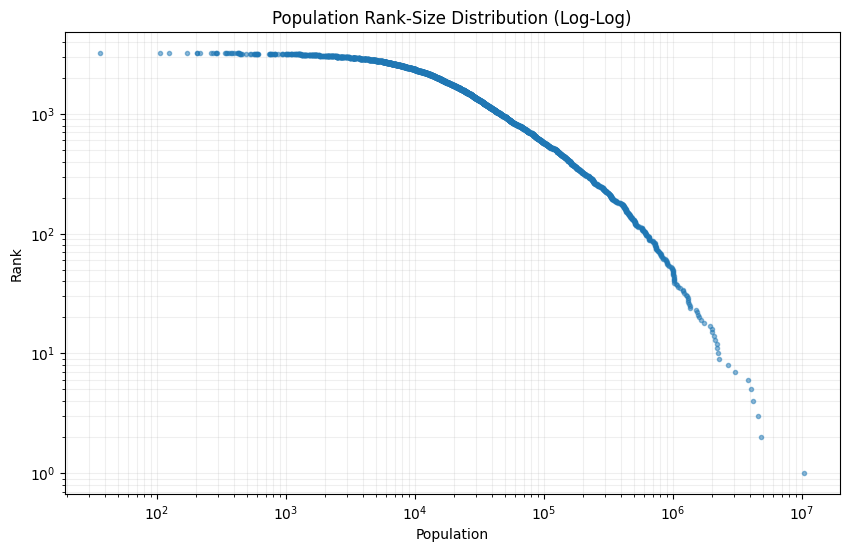

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Sort population from largest to smallest
sorted_pop = np.sort(population)[::-1]
ranks = np.arange(1, len(sorted_pop) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(sorted_pop, ranks, marker='.', linestyle='none', alpha=0.5)
plt.title("Population Rank-Size Distribution (Log-Log)")
plt.ylabel("Rank")
plt.xlabel("Population")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

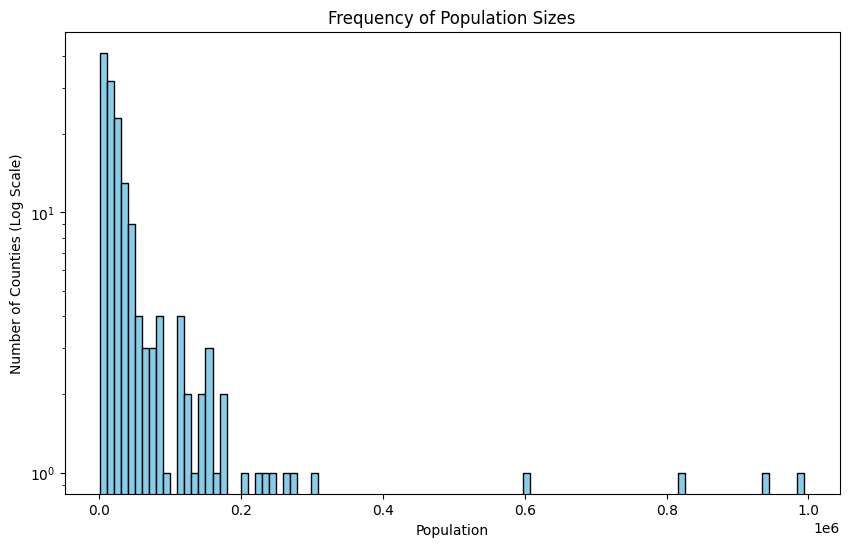

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(population, bins=100, color='skyblue', edgecolor='black', log=True)
plt.title("Frequency of Population Sizes")
plt.xlabel("Population")
plt.ylabel("Number of Counties (Log Scale)")
plt.show()

In [16]:
population.min()

geoid_o                 01001
total_populaiton    36.142857
dtype: object

In [40]:
np.savez_compressed('testing graphs/mobility_metadata_real.npz',
                    population=population)

In [135]:

import torch
from torch_geometric.data import Data
import numpy as np
import os



edge_index = torch.tensor(np.vstack((graph.row, graph.col)), dtype=torch.long)

# 2. edge_attr: Shape [num_edges, 1], type float32
edge_attr = torch.tensor(graph.data, dtype=torch.float32).view(-1, 1)

# 3. x (Node features): Combine population and position, Shape [num_nodes, 3], type float32
node_features = np.column_stack((population, area_distr, positions))
x = torch.tensor(node_features, dtype=torch.float32)

# 4. y (Target label): Shape [1], type float32
y = torch.tensor([threshold], dtype=torch.float32)

# --- Construct PyG Data Object ---
data_obj = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Append to our list
pyg_graph = data_obj

save_path = '/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/georgia.pt'

torch.save(pyg_graph, save_path)




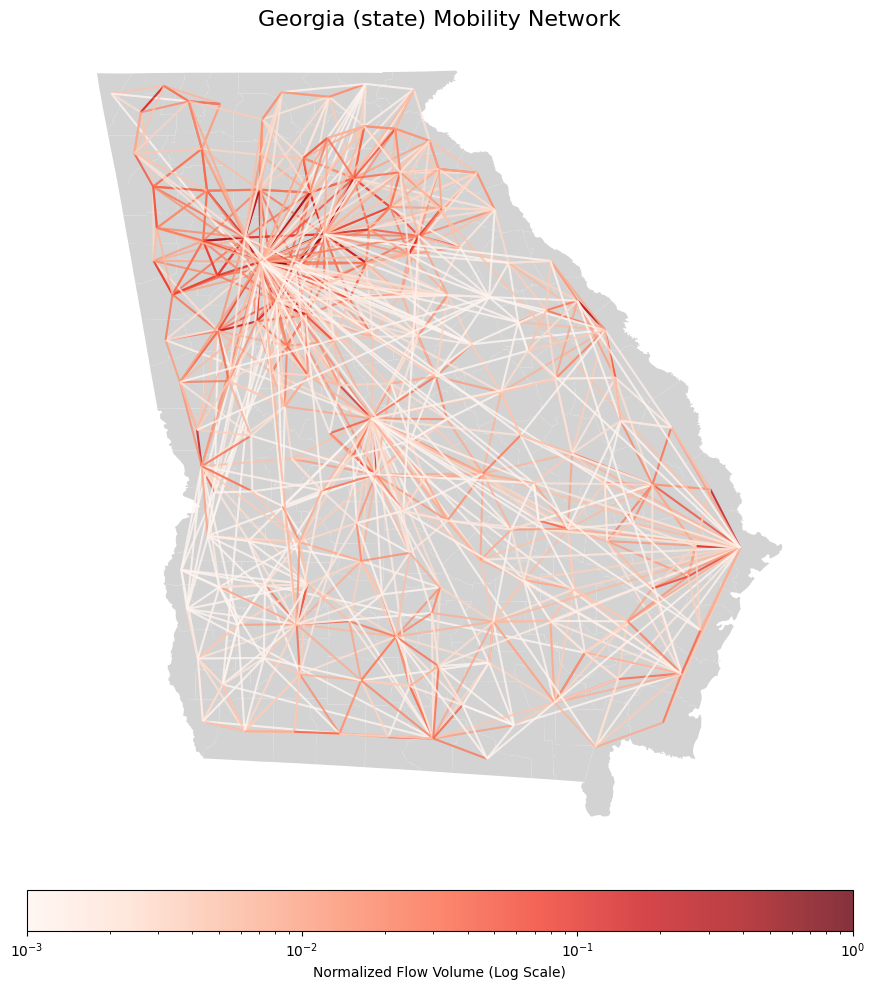

In [15]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
from shapely.geometry import LineString
import warnings

counties['centroid'] = counties.geometry.centroid
coords = dict(zip(counties['GEOID'], zip(counties['centroid'].x, counties['centroid'].y)))

# ==========================================
# 2. PROCESS THE OD MATRIX
# ==========================================
# Filter out self-loops (flows within the same MSOA)
df_OD = df_merged_pop.copy()
df_OD = df_OD[df_OD['geoid_o'] != df_OD['geoid_d']]

active_zones = pd.concat([df_OD['geoid_o'], df_OD['geoid_d']]).unique()
counties_georgia = counties[counties['GEOID'].isin(active_zones)]

df_OD = df_OD[(df_OD['pop_flows'] >= df_OD['total_populaiton'] * 0.01)]
max_flow = df_OD['pop_flows'].max()
df_OD['normalized_flow'] = (df_OD['pop_flows'] / max_flow)


#df_OD = df_OD.drop(columns={'area_km2', 'total_populaiton', 'total_flow'})
# df_OD


lines = []
flow_values = []

for _, row in df_OD.iterrows():
    orig = row['geoid_o']
    dest = row['geoid_d']

    # Only draw lines if we have the coordinates for both origin and destination
    if orig in coords and dest in coords:
        lines.append([coords[orig], coords[dest]])
        flow_values.append(row['normalized_flow'])

fig, ax = plt.subplots(figsize=(10, 10))

# A. Plot the Base Map (Non-hotspots as solid Light Gray)
counties_georgia.plot(
    ax=ax,
    color='#D3D3D3',  # Light Gray
    markersize=15,  # Adjust size if needed
    zorder=1
)

# C. Plot the Mobility Network (Lines)
lc = LineCollection(
    lines,
    cmap='Reds',
    norm=LogNorm(vmin=10 ** -3, vmax=10 ** 0),
    linewidths=1.5,
    alpha=0.8,
    zorder=2  # Lines go on top of the polygons
)
lc.set_array(np.array(flow_values))
ax.add_collection(lc)

# D. Formatting
plt.title(r'Georgia (state) Mobility Network', fontsize=16)
ax.set_axis_off()  # Removes the bounding box and coordinates

# E. Add Colorbar
cbar = plt.colorbar(lc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Normalized Flow Volume (Log Scale)')  #normalized by largest flow!!!!!!
# Lock the aspect ratio so the map doesn't stretch
ax.set_aspect('equal')

plt.tight_layout()
plt.show()



In [31]:
df_OD

,geoid_o,geoid_d,lng_o,lat_o,lng_d,lat_d,date_range,visitor_flows,pop_flows,GEOID,area_km2,total_populaiton,normalized_flow
0,13025,13029,-81.981895,31.196876,-81.442472,32.013224,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286,0.000080
1,13025,13051,-81.981895,31.196876,-81.092425,31.974022,02/11/19 - 02/17/19,81,224.142857,13025,1158.343522,16752.714286,0.001627
2,13025,13059,-81.981895,31.196876,-83.367332,33.951168,02/11/19 - 02/17/19,12,33.142857,13025,1158.343522,16752.714286,0.000241
3,13025,13063,-81.981895,31.196876,-84.357654,33.541901,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286,0.000080
4,13025,13067,-81.981895,31.196876,-84.576673,33.941463,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286,0.000080
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9465,13125,13303,-82.610702,33.229280,-82.795899,32.969536,02/11/19 - 02/17/19,164,347.142857,13125,374.113816,3328.571429,0.002520
9466,13125,13033,-82.610702,33.229280,-82.000781,33.061154,02/11/19 - 02/17/19,5,10.571429,13125,374.113816,3328.571429,0.000077
9467,13125,13039,-82.610702,33.229280,-81.636389,30.922490,02/11/19 - 02/17/19,6,12.571429,13125,374.113816,3328.571429,0.000091
9471,13125,13301,-82.610702,33.229280,-82.676762,33.408963,02/11/19 - 02/17/19,50,105.857143,13125,374.113816,3328.571429,0.000768


In [12]:
def radiation_model(number_nodes, positions, population):
    rows, cols, weights = [], [], []

    for i in range(number_nodes):
        distance = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distance[i] = np.inf
        distance[distance == 0] = 0.1

        #radiation model simini paper
        #flow ij = mi * ( minj/ (mi + sij) * (mi + nj + sij))
        #sij = sum of populations in distance between city i and j minus original

        #change self flow

        all_flows = []
        for j in range(number_nodes):
            if j == i:
                flow = np.random.uniform(0.25, 0.40) * population[i]  #selfflows
            else:
                r_ij = distance[j]
                # print(r_ij)
                # if r_ij > 5000: # distance cutoff
                #     flow = 0
                #     continue
                # else:
                s_ij = population[(distance < r_ij)].sum() - population[i] - population[j]
                s_ij = max(0, s_ij)  #no negative s

                first_term = population[i] * population[j]
                second_term = (population[i] + s_ij) * (population[i] + population[j] + s_ij)
                if second_term > 0:
                    log_flow = np.log(population[i]) + np.log(first_term) - np.log(second_term)
                    flow = np.exp(log_flow)

            all_flows.append(flow)

        #urban scaling theory geoffery west luisbettern court
        # target_k = number_nodes * 0.08
        # k = int(target_k * (population [i]  / np.mean(population))**0.5) #scale based on popualtion
        # k= np.clip(k, 1, 500)
        # top_idx = np.argpartition(all_flows, -k)[-k:]
        # #print(k)

        k = np.random.uniform(0.01, 0.08)
        k = int(k * number_nodes)

        k=100

        top_idx = np.argpartition(all_flows, -k)[-k:]

        for j in top_idx:
            rows.append(i)
            cols.append(j)
            weights.append(all_flows[j])

        #print(flow)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    # weights = weights / row_sums[rows]

    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)





In [43]:
df_merged_pop

,geoid_o,geoid_d,lng_o,lat_o,lng_d,lat_d,date_range,visitor_flows,pop_flows,GEOID,area_km2,total_populaiton
0,13025,13029,-81.981895,31.196876,-81.442472,32.013224,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286
1,13025,13051,-81.981895,31.196876,-81.092425,31.974022,02/11/19 - 02/17/19,81,224.142857,13025,1158.343522,16752.714286
2,13025,13059,-81.981895,31.196876,-83.367332,33.951168,02/11/19 - 02/17/19,12,33.142857,13025,1158.343522,16752.714286
3,13025,13063,-81.981895,31.196876,-84.357654,33.541901,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286
4,13025,13067,-81.981895,31.196876,-84.576673,33.941463,02/11/19 - 02/17/19,4,11.000000,13025,1158.343522,16752.714286
...,...,...,...,...,...,...,...,...,...,...,...,...
9470,13125,13221,-82.610702,33.229280,-83.080703,33.880648,02/11/19 - 02/17/19,4,8.428571,13125,374.113816,3328.571429
9471,13125,13301,-82.610702,33.229280,-82.676762,33.408963,02/11/19 - 02/17/19,50,105.857143,13125,374.113816,3328.571429
9472,13125,13317,-82.610702,33.229280,-82.743227,33.781945,02/11/19 - 02/17/19,6,12.571429,13125,374.113816,3328.571429
9473,13125,13165,-82.610702,33.229280,-81.963532,32.792471,02/11/19 - 02/17/19,4,8.428571,13125,374.113816,3328.571429


In [16]:
import numpy as np

# 1. Sort both dataframes alphabetically by the zip code name to perfectly align them
counties_georgia = counties_georgia.sort_values(by='GEOID').reset_index(drop=True)

# For population, we just want a unique list of zip codes and their populations
pop_table = df_merged_pop[['geoid_o', 'total_populaiton']].drop_duplicates().sort_values(by='geoid_o').reset_index(drop=True)

# Check to ensure they match exactly!
assert (counties_georgia['GEOID'] == pop_table['geoid_o']).all(), "Mismatch between map and population data!"

In [28]:
# Extract the X and Y coordinates from the polygon centroids
x_coords = counties_georgia.geometry.centroid.x.values
y_coords = counties_georgia.geometry.centroid.y.values

# Use column_stack to merge them into a single (N, 2) array: [[x1, y1], [x2, y2]...]
positions = np.column_stack((x_coords, y_coords))

# Extract the population into a simple 1D array
population = pop_table['total_populaiton'].values

# Define your number of nodes
number_nodes = len(positions)
number_nodes

159

In [24]:
def radiation_model(number_nodes, positions, population):
    rows, cols, weights = [], [], []

    for i in range(number_nodes):
        distance = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distance[i] = np.inf
        distance[distance == 0] = 0.1

        #radiation model simini paper
        #flow ij = mi * ( minj/ (mi + sij) * (mi + nj + sij))
        #sij = sum of populations in distance between city i and j minus original

        #change self flow

        all_flows = []
        for j in range(number_nodes):
            if j == i:
                flow = np.random.uniform(0.25, 0.40) * population[i]  #selfflows
            else:
                r_ij = distance[j]
                # print(r_ij)
                # if r_ij > 5000: # distance cutoff
                #     flow = 0
                #     continue
                # else:
                s_ij = population[(distance < r_ij)].sum() - population[i] - population[j]
                s_ij = max(0, s_ij)  #no negative s

                first_term = population[i] * population[j]
                second_term = (population[i] + s_ij) * (population[i] + population[j] + s_ij)
                if second_term > 0:
                    log_flow = np.log(population[i]) + np.log(first_term) - np.log(second_term)
                    flow = np.exp(log_flow)

            all_flows.append(flow)

        #urban scaling theory geoffery west luisbettern court
        # target_k = number_nodes * 0.08
        # k = int(target_k * (population [i]  / np.mean(population))**0.5) #scale based on popualtion
        # k= np.clip(k, 1, 500)
        # top_idx = np.argpartition(all_flows, -k)[-k:]
        # #print(k)

        k = np.random.uniform(0.01, 0.08)
        k = int(k * number_nodes)
        k = 100

        top_idx = np.argpartition(all_flows, -k)[-k:]

        for j in top_idx:
            rows.append(i)
            cols.append(j)
            weights.append(all_flows[j])

        #print(flow)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    # weights = weights / row_sums[rows]

    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)





In [31]:
from scipy.sparse import coo_matrix
import numpy as np


def gravity_model(positions, number_nodes, population):
    rows, cols, weights = [], [], []

    for i in range(number_nodes):
        distances = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distances[i] = np.inf
        distances[distances == 0] = 0.1

        #attraction = g * (m * m) / d^2
        flow = (population[i] * population) / (distances ** 2)
        flow[i] = np.random.uniform(0.25, 0.40) * population[i]
        flow = np.asarray(flow).flatten()
        # print(type(flow))
        # print(np.shape(flow))

        # # only keeo flows above threshold
        # threshold = np.percentile(flow [flow > 0], 90) #threshol is 10% most attractive cities
        # desitnations_index = np.where(flow > threshold)[0]
        #
        # k = np.random.randint(3, 30)

        k = np.random.uniform(0.01, 0.08)
        k = int(k * number_nodes)
        desitnations_index = np.argsort(flow)[-k:]

        k = 200

        # k = np.random.uniform(0.05, 0.12)
        # k= int(k * number_nodes)
        # desitnations_index = np.argpartition(flow, -k)[-k:]

        for j in desitnations_index:
            rows.append(i)
            cols.append(j)
            weights.append(flow[j])
        #print(flow)

    rows = np.array(rows)
    cols = np.array(cols)
    weights = np.array(weights)

    #print(weights)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    # weights = weights / row_sums[rows]  #normalis weights
    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)


In [25]:
rows, cols, weights = radiation_model(number_nodes, positions, population)

In [32]:
rows, cols, weights = gravity_model(positions, number_nodes, population)

In [26]:
from scipy.sparse import coo_matrix

In [33]:
graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
graph = graph.tocsr()

In [125]:
import pandas as pd

# 1. Create the basic DataFrame from your model's output arrays
df_model_flows = pd.DataFrame({
    'origin_idx': rows,
    'dest_idx': cols,
    'flow_volume': weights
})

# 2. Map the integer indices back to your actual Postcode District names
# (Assuming your pop_table or zipcodes_gdf is still sorted in the exact
# same order you used to feed the model)
zone_names = pop_table['geoid_o'].values

# Create new columns with the actual names
df_model_flows['geoid_o'] = df_model_flows['origin_idx'].map(lambda x: zone_names[x])
df_model_flows['geoid_d'] = df_model_flows['dest_idx'].map(lambda x: zone_names[x])

# 3. Clean up the DataFrame to match your visualization script's expected format
df_model_flows = df_model_flows[['geoid_o', 'geoid_d', 'flow_volume']]

# 4. Filter out self-loops (optional, but good for visualization)
df_model_flows = df_model_flows[df_model_flows['geoid_o'] != df_model_flows['geoid_d']]

# 2. Merge the population column directly from pop_table
df_model_flows = df_model_flows.merge(
    pop_table[['geoid_o', 'total_populaiton']],
    on='geoid_o',
    how='left'
)

df_model_flows

,geoid_o,geoid_d,flow_volume,total_populaiton
0,13001,13279,0.283880,17285.571429
1,13001,13267,0.288970,17285.571429
2,13001,13305,0.304124,17285.571429
3,13001,13051,0.342400,17285.571429
4,13003,13121,0.076134,7340.285714
...,...,...,...,...
870,13321,13121,0.341941,21243.428571
871,13321,13177,0.525640,21243.428571
872,13321,13071,0.563576,21243.428571
873,13321,13277,0.931625,21243.428571


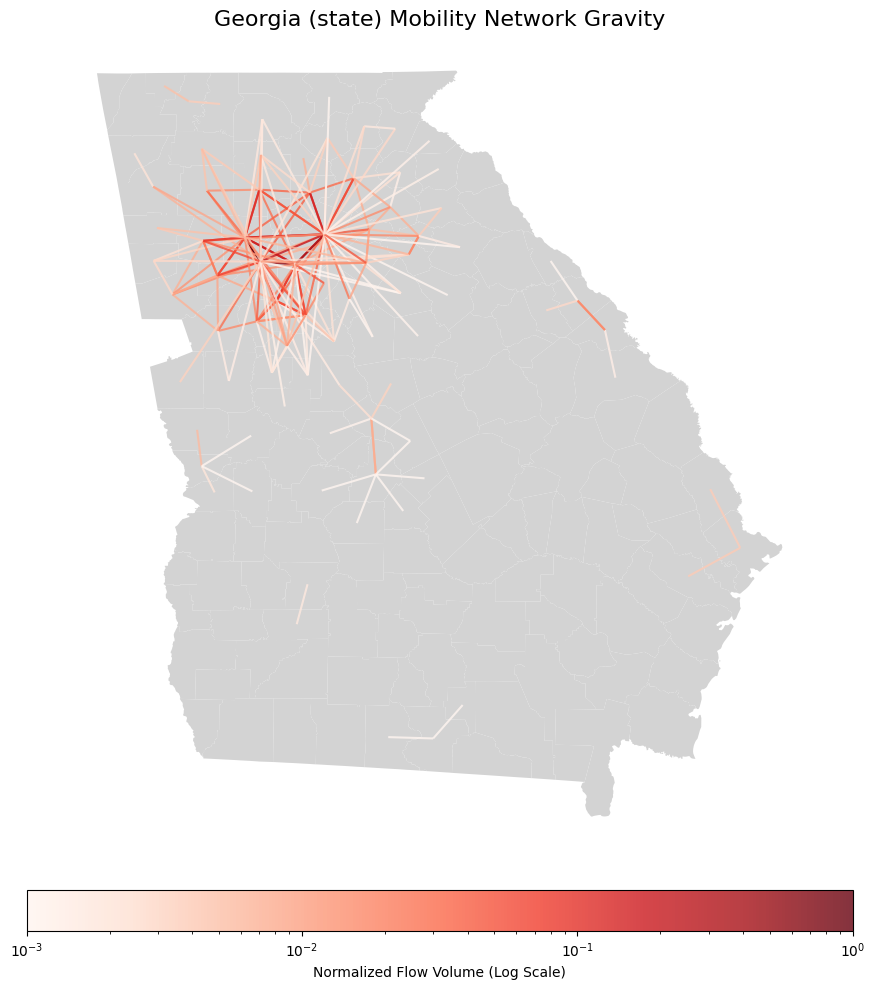

In [133]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
from shapely.geometry import LineString
import warnings

counties['centroid'] = counties.geometry.centroid
coords = dict(zip(counties['GEOID'], zip(counties['centroid'].x, counties['centroid'].y)))

# ==========================================
# 2. PROCESS THE OD MATRIX
# ==========================================
# Filter out self-loops (flows within the same MSOA)
df_OD = df_model_flows.copy()
df_OD = df_OD[df_OD['geoid_o'] != df_OD['geoid_d']]

active_zones = pd.concat([df_OD['geoid_o'], df_OD['geoid_d']]).unique()
counties_georgia = counties[counties['GEOID'].isin(active_zones)]

df_OD = df_OD[(df_OD['flow_volume'] >= df_OD['total_populaiton'] * 0.0001)]
max_flow = df_OD['flow_volume'].max()
df_OD['normalized_flow'] = (df_OD['flow_volume'] / max_flow)

#df_OD = df_OD.drop(columns={'area_km2', 'total_populaiton', 'total_flow'})
# df_OD


lines = []
flow_values = []

for _, row in df_OD.iterrows():
    orig = row['geoid_o']
    dest = row['geoid_d']

    # Only draw lines if we have the coordinates for both origin and destination
    if orig in coords and dest in coords:
        lines.append([coords[orig], coords[dest]])
        flow_values.append(row['normalized_flow'])

fig, ax = plt.subplots(figsize=(10, 10))

# A. Plot the Base Map (Non-hotspots as solid Light Gray)
counties_georgia.plot(
    ax=ax,
    color='#D3D3D3',  # Light Gray
    markersize=15,  # Adjust size if needed
    zorder=1
)

# C. Plot the Mobility Network (Lines)
lc = LineCollection(
    lines,
    cmap='Reds',
    norm=LogNorm(vmin=10 ** -3, vmax=10 ** 0),
    linewidths=1.5,
    alpha=0.8,
    zorder=2  # Lines go on top of the polygons
)
lc.set_array(np.array(flow_values))
ax.add_collection(lc)

# D. Formatting
plt.title(r'Georgia (state) Mobility Network Gravity', fontsize=16)
ax.set_axis_off()  # Removes the bounding box and coordinates

# E. Add Colorbar
cbar = plt.colorbar(lc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Normalized Flow Volume (Log Scale)')  #normalized by largest flow!!!!!!
# Lock the aspect ratio so the map doesn't stretch
ax.set_aspect('equal')

plt.tight_layout()
plt.show()



In [130]:
df_OD

,geoid_o,geoid_d,flow_volume,total_populaiton,normalized_flow
0,13001,13279,0.283880,17285.571429,0.000130
1,13001,13267,0.288970,17285.571429,0.000133
2,13001,13305,0.304124,17285.571429,0.000140
3,13001,13051,0.342400,17285.571429,0.000157
4,13003,13121,0.076134,7340.285714,0.000035
...,...,...,...,...,...
870,13321,13121,0.341941,21243.428571,0.000157
871,13321,13177,0.525640,21243.428571,0.000241
872,13321,13071,0.563576,21243.428571,0.000259
873,13321,13277,0.931625,21243.428571,0.000427


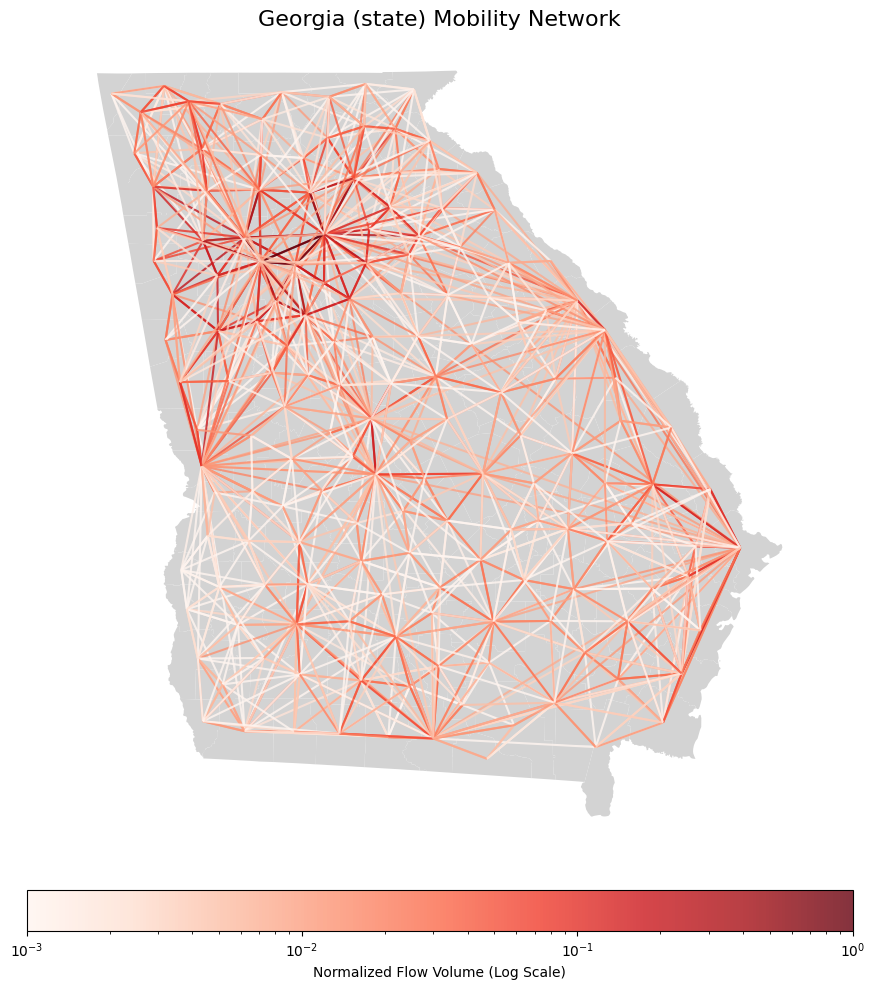

In [113]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
from shapely.geometry import LineString
import warnings

counties['centroid'] = counties.geometry.centroid
coords = dict(zip(counties['GEOID'], zip(counties['centroid'].x, counties['centroid'].y)))

# ==========================================
# 2. PROCESS THE OD MATRIX
# ==========================================
# Filter out self-loops (flows within the same MSOA)
df_OD = df_model_flows.copy()
df_OD = df_OD[df_OD['geoid_o'] != df_OD['geoid_d']]

active_zones = pd.concat([df_OD['geoid_o'], df_OD['geoid_d']]).unique()
counties_georgia = counties[counties['GEOID'].isin(active_zones)]

df_OD = df_OD[(df_OD['flow_volume'] >= df_OD['total_populaiton'] * 0.01)]
max_flow = df_OD['flow_volume'].max()
df_OD['normalized_flow'] = (df_OD['flow_volume'] / max_flow)

#df_OD = df_OD.drop(columns={'area_km2', 'total_populaiton', 'total_flow'})
# df_OD


lines = []
flow_values = []

for _, row in df_OD.iterrows():
    orig = row['geoid_o']
    dest = row['geoid_d']

    # Only draw lines if we have the coordinates for both origin and destination
    if orig in coords and dest in coords:
        lines.append([coords[orig], coords[dest]])
        flow_values.append(row['normalized_flow'])

fig, ax = plt.subplots(figsize=(10, 10))

# A. Plot the Base Map (Non-hotspots as solid Light Gray)
counties_georgia.plot(
    ax=ax,
    color='#D3D3D3',  # Light Gray
    markersize=15,  # Adjust size if needed
    zorder=1
)

# C. Plot the Mobility Network (Lines)
lc = LineCollection(
    lines,
    cmap='Reds',
    norm=LogNorm(vmin=10 ** -3, vmax=10 ** 0),
    linewidths=1.5,
    alpha=0.8,
    zorder=2  # Lines go on top of the polygons
)
lc.set_array(np.array(flow_values))
ax.add_collection(lc)

# D. Formatting
plt.title(r'Georgia (state) Mobility Network', fontsize=16)
ax.set_axis_off()  # Removes the bounding box and coordinates

# E. Add Colorbar
cbar = plt.colorbar(lc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Normalized Flow Volume (Log Scale)')  #normalized by largest flow!!!!!!
# Lock the aspect ratio so the map doesn't stretch
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

